<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%203/L01_MP_Neuron_and_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=VOxWdQxWcLg) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%203/NPTEL_Jul24_DL4CV_W03_P01.pdf)

In [1]:
# Week 3, Lecture 1: Neural Networks Part 1
from IPython.display import HTML, display

VIDEO_ID = "VOxWdQxWcLg"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 3, Lecture 1: The McCulloch-Pitts Neuron and the Perceptron

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§3.1 Neural Networks: A Review**.

This notebook is the hands-on companion to the first lecture. We build the two
oldest artificial neurons from scratch with plain tensors, then reproduce them
with idiomatic PyTorch, and finish by watching the Perceptron Learning Algorithm
converge and understanding *why* its update rule works, geometrically.

**What you will learn**
- The **McCulloch-Pitts (MP) neuron** (1943): sum the inputs, threshold at $\theta$, and let any inhibitory input veto the output. Use it to realize Boolean gates.
- The **Perceptron** (Rosenblatt, 1958): the MP neuron with real weights, and the **bias trick** ($x_0 = 1$, $w_0 = -\theta$) that turns the rule into $w^\top x \ge 0$.
- The **Perceptron Learning Algorithm (PLA)** from scratch on a linearly separable 2D dataset, with an animation of the decision boundary converging.
- The **geometric intuition**: $w$ is perpendicular to the decision line, and adding $x$ to $w$ shrinks the angle toward the correct side.
- The connection from the from-scratch version to a PyTorch `nn.Linear`.

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

**Contents**

1. The McCulloch-Pitts neuron (1943)
2. The Perceptron (Rosenblatt, 1958)
3. The Perceptron Learning Algorithm
4. Why the update rule works (geometric intuition)
5. The perceptron as a PyTorch `nn.Linear`

## Review

Weeks 1 and 2 built vision by hand: linear filters, edges, corners, SIFT and HOG descriptors, closing with the human visual system that inspired them. From here the features are **learned** rather than designed. This lecture starts at the beginning, with the first mathematical models of a neuron.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and local Jupyter.
import sys, subprocess
# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Dropdown, Checkbox, fixed
%matplotlib inline

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Use a GPU if one is available, otherwise CPU. Every demo here is tiny and
# runs in seconds on CPU, so no GPU is required.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.8.0 | device: cpu


## 1. The McCulloch-Pitts neuron (1943)

McCulloch (a neuroscientist) and Pitts (a logician) proposed a highly simplified
model of a neuron. A function $g$ **aggregates** the inputs and a function $f$
takes a **decision** by thresholding:

$$ g(x_1, x_2, \dots, x_n) = \sum_{i=1}^{n} x_i, \qquad y = f(g(x)) = \begin{cases} 1 & \text{if } g(x) \ge \theta \\ 0 & \text{if } g(x) < \theta \end{cases} $$

- Inputs are Boolean ($0$ or $1$) and can be **excitatory** or **inhibitory**.
- **Any active inhibitory input forces $y = 0$**, no matter what the sum is.
- $\theta$ is a threshold we choose by hand (there is no learning yet).

Feedforward MP networks can compute **any** Boolean function. We start bottom-up:
first write the neuron with tensors, then choose $\theta$ to get AND, OR and NOR.

In [3]:
def all_binary_inputs(n):
    """All 2**n Boolean input rows, ordered 0..2**n-1 (most significant bit first)."""
    idx = torch.arange(2 ** n)
    shifts = torch.arange(n - 1, -1, -1)
    bits = (idx.unsqueeze(1) >> shifts) & 1
    return bits.to(torch.float32)


def mp_neuron(x, theta, inhibitory_mask=None):
    """McCulloch-Pitts neuron.

    g(x) = sum_i x_i ; y = 1 if g(x) >= theta else 0.
    Any active inhibitory input (x_i = 1 where the mask is True) forces y = 0.

    x: 0/1 tensor of shape (n,) or (batch, n).
    theta: threshold (a number).
    inhibitory_mask: bool tensor of shape (n,); True marks an inhibitory input.
    """
    x = torch.as_tensor(x, dtype=torch.float32)
    if x.dim() == 1:
        x = x.unsqueeze(0)
    n = x.shape[-1]
    if inhibitory_mask is None:
        inhibitory_mask = torch.zeros(n, dtype=torch.bool)
    inhibitory_mask = torch.as_tensor(inhibitory_mask, dtype=torch.bool)

    g = x.sum(dim=-1)                                  # aggregation g(x)
    fires = (g >= theta).to(torch.int64)               # threshold at theta
    inhibited = (x.bool() & inhibitory_mask).any(dim=-1)
    y = torch.where(inhibited, torch.zeros_like(fires), fires)
    return y.squeeze(0) if y.shape[0] == 1 else y


# Quick sanity check on a couple of single input vectors.
print("g(1,1) >= 2 ?", mp_neuron(torch.tensor([1.0, 1.0]), theta=2).item())
print("g(1,0) >= 2 ?", mp_neuron(torch.tensor([1.0, 0.0]), theta=2).item())

g(1,1) >= 2 ? 1
g(1,0) >= 2 ? 0


### Boolean gates by choosing $\theta$

With two excitatory inputs and $g(x) = x_1 + x_2$:
- **OR** fires whenever the sum is at least $1$, so $\theta = 1$.
- **AND** fires only when the sum is $2$, so $\theta = 2$.

**NOR** cannot come from a plain threshold on the sum (it decreases as the sum
grows), so we use **inhibitory** inputs: set $\theta = 0$ (fires when the sum is
$0$) and mark **both** inputs inhibitory, so any $1$ vetoes the output. We also
show an inhibitory input forcing $y = 0$ inside an otherwise OR-like neuron.

In [4]:
def truth_table(theta, inhibitory_mask, names=("x1", "x2")):
    """Print the full truth table of an MP neuron for the given settings."""
    X = all_binary_inputs(len(names))
    Y = mp_neuron(X, theta, inhibitory_mask)
    print(f"theta = {theta}, inhibitory mask = {inhibitory_mask.tolist()}")
    header = "  ".join(names) + "  | y"
    print(header)
    print("-" * len(header))
    for row, out in zip(X.tolist(), Y.tolist()):
        print("   ".join(str(int(v)) for v in row) + "   | " + str(int(out)))
    print()


no_inh = torch.tensor([False, False])
print("AND gate (theta = 2, both excitatory)")
truth_table(2, no_inh)
print("OR gate (theta = 1, both excitatory)")
truth_table(1, no_inh)
print("NOR gate (theta = 0, both inputs inhibitory)")
truth_table(0, torch.tensor([True, True]))
print("Inhibitory veto (theta = 1, but x2 is inhibitory): whenever x2 = 1, y = 0")
truth_table(1, torch.tensor([False, True]))

AND gate (theta = 2, both excitatory)
theta = 2, inhibitory mask = [False, False]
x1  x2  | y
-----------
0   0   | 0
0   1   | 0
1   0   | 0
1   1   | 1

OR gate (theta = 1, both excitatory)
theta = 1, inhibitory mask = [False, False]
x1  x2  | y
-----------
0   0   | 0
0   1   | 1
1   0   | 1
1   1   | 1

NOR gate (theta = 0, both inputs inhibitory)
theta = 0, inhibitory mask = [True, True]
x1  x2  | y
-----------
0   0   | 1
0   1   | 0
1   0   | 0
1   1   | 0

Inhibitory veto (theta = 1, but x2 is inhibitory): whenever x2 = 1, y = 0
theta = 1, inhibitory mask = [False, True]
x1  x2  | y
-----------
0   0   | 0
0   1   | 0
1   0   | 1
1   1   | 0



### Widget 1: explore MP gates

Move the $\theta$ slider and toggle whether each input is inhibitory. The four
corners of the unit square are the Boolean inputs $(x_1, x_2)$, colored by the
neuron output $y$. The title tells you which standard gate (if any) the current
settings implement. Try $\theta = 1$ then $\theta = 2$ (OR to AND), and try
$\theta = 0$ with both inputs inhibitory (NOR).

In [5]:
GATE_TABLES = {
    (0, 0, 0, 0): "ALWAYS 0",
    (0, 0, 0, 1): "AND",
    (0, 1, 1, 1): "OR",
    (1, 0, 0, 0): "NOR",
    (1, 1, 1, 0): "NAND",
    (0, 1, 1, 0): "XOR",
    (1, 0, 0, 1): "XNOR",
    (1, 1, 1, 1): "ALWAYS 1",
    (0, 0, 1, 1): "x1",
    (0, 1, 0, 1): "x2",
    (1, 1, 0, 0): "NOT x1",
    (1, 0, 1, 0): "NOT x2",
    (0, 0, 1, 0): "x1 AND (NOT x2)",
    (0, 1, 0, 0): "x2 AND (NOT x1)",
}


def identify_gate(outputs4):
    """Name the 2-input gate from its output column, ordered (0,0),(0,1),(1,0),(1,1)."""
    key = tuple(int(v) for v in outputs4)
    return GATE_TABLES.get(key, "custom (not a standard 2-input gate)")


def mp_gate_explorer(theta=1, x1_inhibitory=False, x2_inhibitory=False):
    mask = torch.tensor([bool(x1_inhibitory), bool(x2_inhibitory)])
    X = all_binary_inputs(2)                       # rows (0,0),(0,1),(1,0),(1,1)
    Y = mp_neuron(X, theta, mask)
    outs = [int(v) for v in Y.tolist()]
    name = identify_gate(outs)

    fig, ax = plt.subplots(figsize=(5, 5))
    colors = ["tab:blue" if o == 1 else "tab:red" for o in outs]
    ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=colors, s=500,
               edgecolor="k", zorder=3)
    for (px, py), o in zip(X.tolist(), outs):
        ax.annotate(str(o), (px, py), ha="center", va="center",
                    color="white", fontsize=15, fontweight="bold", zorder=4)
    # Proxy handles for a clean legend.
    ax.scatter([], [], c="tab:blue", s=120, edgecolor="k", label="y = 1 (fires)")
    ax.scatter([], [], c="tab:red", s=120, edgecolor="k", label="y = 0")

    inh = [nm for nm, m in zip(("x1", "x2"), (x1_inhibitory, x2_inhibitory)) if m]
    inh_txt = "none" if not inh else ", ".join(inh)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(f"MP neuron: theta = {theta}, inhibitory = {inh_txt}\n"
                 f"truth table {tuple(outs)} = {name}")
    ax.legend(loc="upper left", framealpha=0.9)
    plt.show()


interact(mp_gate_explorer,
         theta=IntSlider(min=0, max=3, step=1, value=1),
         x1_inhibitory=Checkbox(value=False, description="x1 inhibitory"),
         x2_inhibitory=Checkbox(value=False, description="x2 inhibitory"));

interactive(children=(IntSlider(value=1, description='theta', max=3), Checkbox(value=False, description='x1 in…

## 2. The Perceptron (Rosenblatt, 1958)

Rosenblatt generalized the MP neuron; it was later analyzed carefully by Minsky
and Papert (1969). Two changes: inputs are no longer limited to Boolean values,
and each input gets a real **weight** $w_i$:

$$ g(x) = \sum_{i=1}^{n} w_i\, x_i, \qquad y = 1 \text{ if } g(x) \ge \theta,\ \text{else } 0. $$

**The bias trick (a more convenient convention).** Introduce a constant input
$x_0 = 1$ with weight $w_0 = -\theta$. Then the threshold moves into the sum:

$$ \sum_{i=0}^{n} w_i\, x_i = w^\top x, \qquad y = 1 \text{ if } w^\top x \ge 0,\ \text{else } 0. $$

So a perceptron is just a **weighted vote with a bias**, thresholded at $0$.
Below we reuse the bias trick to realize the same AND and OR gates from Part A,
now with real weights instead of a hand-picked $\theta$.

In [6]:
def perceptron(x, w):
    """Perceptron with the bias trick.

    x: real-valued inputs of shape (n,) or (batch, n), WITHOUT the bias term.
    w: weights of shape (n+1,), where w[0] = -theta is the bias.
    Prepends x0 = 1 and fires (y = 1) if w^T x >= 0, else y = 0.
    """
    x = torch.as_tensor(x, dtype=torch.float32)
    if x.dim() == 1:
        x = x.unsqueeze(0)
    ones = torch.ones(x.shape[0], 1)
    x_aug = torch.cat([ones, x], dim=1)               # prepend x0 = 1
    w = torch.as_tensor(w, dtype=torch.float32)
    score = x_aug @ w
    y = (score >= 0).to(torch.int64)
    return y.squeeze(0) if y.shape[0] == 1 else y


inputs = all_binary_inputs(2)
w_or = torch.tensor([-1.0, 1.0, 1.0])                 # theta = 1  -> OR
w_and = torch.tensor([-2.0, 1.0, 1.0])               # theta = 2  -> AND
print("inputs (x1, x2):", [tuple(int(v) for v in r) for r in inputs.tolist()])
print("OR  with w = [-1, 1, 1] :", perceptron(inputs, w_or).tolist())
print("AND with w = [-2, 1, 1] :", perceptron(inputs, w_and).tolist())

inputs (x1, x2): [(0, 0), (0, 1), (1, 0), (1, 1)]
OR  with w = [-1, 1, 1] : [0, 1, 1, 1]
AND with w = [-2, 1, 1] : [0, 0, 0, 1]


Notice the output is a **hard step**: it jumps from $0$ to $1$ at the threshold
and says nothing about *how* confident the neuron is. Lecture 2 will replace this
step with a smooth sigmoid so the neuron becomes differentiable and trainable by
gradient descent; here we stay with the step and learn the weights a different
way.

## 3. The Perceptron Learning Algorithm

We now *learn* $w$ instead of setting it by hand. Let $P$ be the inputs with
label $1$ and $N$ the inputs with label $0$. Each input carries the bias term
$x = [1, x_1, x_2, \dots]$. The algorithm is:

```
Initialize w randomly
while not converged:
    pick a point x
    if x in P and w^T x <  0:   w = w + x     # P point on the wrong side
    if x in N and w^T x >= 0:   w = w - x     # N point on the wrong side
# converged when every point is classified correctly
```

The intuition: if a positive point is misclassified we push $w$ **toward** it;
if a negative point is misclassified we push $w$ **away** from it. We implement
this exactly, generate two Gaussian blobs (linearly separable) with numpy, add
the $x_0 = 1$ bias column, and record $w$ and the misclassified count after every
update so we can replay the run.

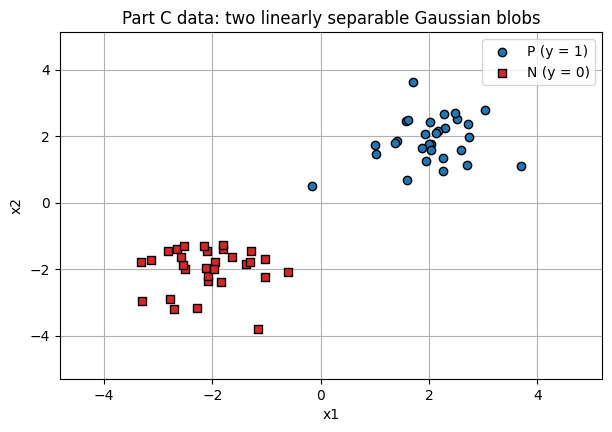

X_np shape: (60, 3) (columns are [1, x1, x2])


In [7]:
# Two Gaussian blobs in 2D, made with numpy (linearly separable).
rng = np.random.default_rng(1)
n_per = 30
mu_P = np.array([2.0, 2.0])          # class P (label 1)
mu_N = np.array([-2.0, -2.0])        # class N (label 0)
sigma = 0.8
XP = rng.normal(mu_P, sigma, size=(n_per, 2))
XN = rng.normal(mu_N, sigma, size=(n_per, 2))

X_raw = np.vstack([XP, XN]).astype(np.float32)                 # (2n, 2) coordinates
y_np = np.concatenate([np.ones(n_per), np.zeros(n_per)]).astype(np.float32)

# Bias trick: prepend the constant column x0 = 1  ->  columns become [1, x1, x2].
X_np = np.hstack([np.ones((X_raw.shape[0], 1), dtype=np.float32), X_raw])

X_t = torch.from_numpy(X_np)
y_t = torch.from_numpy(y_np)

# Fixed view limits so every later frame lines up.
pad = 1.5
XLIM = (float(X_raw[:, 0].min() - pad), float(X_raw[:, 0].max() + pad))
YLIM = (float(X_raw[:, 1].min() - pad), float(X_raw[:, 1].max() + pad))

fig, ax = plt.subplots()
ax.scatter(XP[:, 0], XP[:, 1], c="tab:blue", edgecolor="k", label="P (y = 1)")
ax.scatter(XN[:, 0], XN[:, 1], c="tab:red", marker="s", edgecolor="k", label="N (y = 0)")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Part C data: two linearly separable Gaussian blobs")
ax.legend(loc="best")
plt.show()

print("X_np shape:", X_np.shape, "(columns are [1, x1, x2])")

In [8]:
def train_perceptron(X, y, max_epochs=100, seed=0, init_scale=10.0):
    """Perceptron Learning Algorithm from scratch (with the bias trick).

    X: (N, d) tensor whose first column is the bias input x0 = 1.
    y: (N,) tensor with 1 for class P and 0 for class N.
    Records w and the misclassified count after every weight update, so the
    whole run can be replayed frame by frame. We start from a deliberately large
    random w (init_scale) so convergence takes several visible steps to watch.
    """
    torch.manual_seed(seed)
    N, d = X.shape
    w = init_scale * torch.randn(d)                   # large random init, on purpose

    def n_mis(w):
        pred = (X @ w >= 0).float()
        return int((pred != y).sum().item())

    snaps = [{"w": w.clone(), "mis": n_mis(w), "step": 0}]
    step = 0
    for _ in range(max_epochs):
        updated = False
        for i in range(N):
            score = torch.dot(w, X[i])
            if y[i] == 1 and score < 0:              # x in P, wrong side
                w = w + X[i]
            elif y[i] == 0 and score >= 0:           # x in N, wrong side
                w = w - X[i]
            else:
                continue
            updated = True
            step += 1
            snaps.append({"w": w.clone(), "mis": n_mis(w), "step": step})
        if not updated:
            break                                    # a full clean pass = converged
    return w, snaps


w_learned, snapshots = train_perceptron(X_t, y_t)
print(f"converged after {len(snapshots) - 1} weight updates")
print("final w = [w0, w1, w2] =", np.round(w_learned.numpy(), 3))
print("final misclassified:", snapshots[-1]["mis"], "of", len(y_t), "points")

converged after 11 weight updates
final w = [w0, w1, w2] = [16.41  17.137  5.516]
final misclassified: 0 of 60 points


### A reusable boundary plotter

`plot_boundary` scatters the two classes, draws the decision line $w^\top x = 0$,
and draws the weight vector $w = (w_1, w_2)$ as an arrow **rooted on the line**.
Because $w$ is the normal to the line, the arrow meets the line at a right angle,
a fact we make precise in Part D.

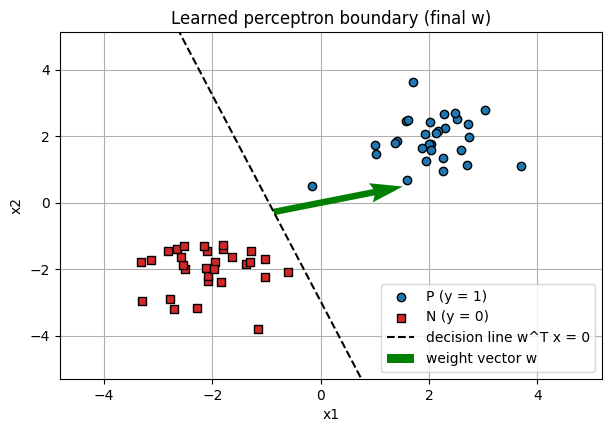

In [9]:
def plot_boundary(w, X, y, ax=None, xlim=None, ylim=None, title=None):
    """Scatter classes P and N, draw the decision line w^T x = 0, and draw the
    weight vector (w1, w2) as an arrow rooted on the line (w is its normal).

    X columns are [1, x1, x2]; w = [w0, w1, w2].
    """
    w = np.asarray(w, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    y = np.asarray(y).ravel()
    coords = X[:, 1:]
    if ax is None:
        _, ax = plt.subplots()
    if xlim is None:
        xlim = (coords[:, 0].min() - 1.5, coords[:, 0].max() + 1.5)
    if ylim is None:
        ylim = (coords[:, 1].min() - 1.5, coords[:, 1].max() + 1.5)

    P = y == 1
    Nmask = y == 0
    ax.scatter(coords[P, 0], coords[P, 1], c="tab:blue", edgecolor="k", label="P (y = 1)")
    ax.scatter(coords[Nmask, 0], coords[Nmask, 1], c="tab:red", marker="s",
               edgecolor="k", label="N (y = 0)")

    w0, w1, w2 = w
    xs = np.linspace(xlim[0], xlim[1], 200)
    if abs(w2) > 1e-9:
        ys = -(w0 + w1 * xs) / w2
        ax.plot(xs, ys, "k--", label="decision line w^T x = 0")
    elif abs(w1) > 1e-9:
        ax.axvline(-w0 / w1, color="k", ls="--", label="decision line w^T x = 0")

    # Weight vector: root it at the foot of the perpendicular from the origin.
    normal = np.array([w1, w2])
    nrm2 = float(normal @ normal) + 1e-12
    foot = (-w0 / nrm2) * normal
    length = 0.25 * (xlim[1] - xlim[0])
    unit = normal / (np.linalg.norm(normal) + 1e-12)
    ax.quiver(foot[0], foot[1], unit[0] * length, unit[1] * length,
              angles="xy", scale_units="xy", scale=1, color="green",
              width=0.012, label="weight vector w")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title:
        ax.set_title(title)
    ax.legend(loc="best")
    return ax


fig, ax = plt.subplots()
plot_boundary(w_learned, X_np, y_np, ax=ax, xlim=XLIM, ylim=YLIM,
              title="Learned perceptron boundary (final w)")
plt.show()

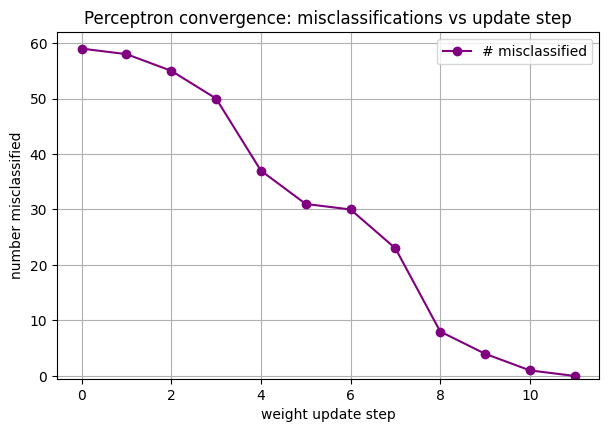

In [10]:
# Convergence curve: misclassifications after each weight update.
mis = [s["mis"] for s in snapshots]
steps = [s["step"] for s in snapshots]

fig, ax = plt.subplots()
ax.plot(steps, mis, marker="o", color="purple", label="# misclassified")
ax.set_xlabel("weight update step")
ax.set_ylabel("number misclassified")
ax.set_title("Perceptron convergence: misclassifications vs update step")
ax.set_ylim(bottom=-0.5)
ax.legend(loc="best")
plt.show()

### Widget 2: watch the boundary converge

All snapshots were precomputed above, so this slider just indexes into them and
redraws. Drag **step** from $0$ (random initial $w$) to the end and watch the
decision line and the weight-vector arrow swing into place until no point is
misclassified.

In [11]:
def show_pla_step(step=0):
    snap = snapshots[step]
    fig, ax = plt.subplots()
    plot_boundary(snap["w"], X_np, y_np, ax=ax, xlim=XLIM, ylim=YLIM,
                  title=f"PLA step {step} of {len(snapshots) - 1}   |   "
                        f"misclassified = {snap['mis']}")
    plt.show()


interact(show_pla_step,
         step=IntSlider(min=0, max=len(snapshots) - 1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='step', max=11), Output()), _dom_classes=('widget-interac…

## 4. Why the update rule works (geometric intuition)

This is the heart of the lecture. We seek the line $w^\top x = 0$ that splits the
plane into two halves. For any point $x$ **on** the line, $w^\top x = 0$, and
since

$$ \cos \alpha = \frac{w^\top x}{\lVert w \rVert\, \lVert x \rVert}, $$

the angle $\alpha$ between $w$ and such an $x$ is $90^\circ$. So **$w$ is
perpendicular to the line**. This splits the plane by angle:
- For $x \in P$ we want $w^\top x > 0$, i.e. angle $\alpha < 90^\circ$.
- For $x \in N$ we want $w^\top x < 0$, i.e. angle $\alpha > 90^\circ$.

**Why adding $x$ helps.** If $x \in P$ is misclassified then $w^\top x < 0$
(angle too big). The update $w_{new} = w + x$ gives

$$ \cos \alpha_{new} \propto w_{new}^\top x = (w + x)^\top x = w^\top x + x^\top x \propto \cos \alpha + \lVert x \rVert^2. $$

Since $x^\top x = \lVert x \rVert^2 > 0$, we get $\cos \alpha_{new} > \cos \alpha$,
so $\alpha_{new} < \alpha$: the angle shrinks toward the side we want. The $x \in N$
case with $w_{new} = w - x$ works out the same way. That is exactly why the
update rule converges on separable data.

### Widget 3: the angle and the sign of $w^\top x$

Fix a weight $w$ (green arrow) and move a point $x$ (the blue or red arrow)
around a circle with the **angle** slider. The background is shaded by the sign
of $w^\top x$: blue is the $P$ side ($w^\top x > 0$, angle below $90^\circ$), red
is the $N$ side ($w^\top x < 0$, angle above $90^\circ$). Watch the point flip
color exactly as it crosses the dashed decision line.

In [12]:
w_geo = np.array([1.0, 1.0])         # a fixed weight; it is the normal to the line
R = 2.0                              # keep the moving point on a circle of this radius


def geometry_demo(angle_deg=30):
    a = np.deg2rad(angle_deg)
    x = R * np.array([np.cos(a), np.sin(a)])
    dot = float(w_geo @ x)
    cos_alpha = dot / (np.linalg.norm(w_geo) * np.linalg.norm(x) + 1e-12)
    alpha = np.degrees(np.arccos(np.clip(cos_alpha, -1.0, 1.0)))
    if dot > 1e-9:
        verdict = "w^T x > 0, angle < 90 deg  ->  classified as P"
    elif dot < -1e-9:
        verdict = "w^T x < 0, angle > 90 deg  ->  classified as N"
    else:
        verdict = "w^T x = 0, angle = 90 deg  ->  on the line"

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    lim = 3.0
    xx, yy = np.meshgrid(np.linspace(-lim, lim, 200), np.linspace(-lim, lim, 200))
    Z = w_geo[0] * xx + w_geo[1] * yy
    ax.contourf(xx, yy, Z, levels=[Z.min() - 1, 0, Z.max() + 1],
                colors=["#ffe0e0", "#e0e0ff"], alpha=0.6)

    d = np.array([-w_geo[1], w_geo[0]])
    d = d / np.linalg.norm(d)
    ax.plot([-lim * d[0], lim * d[0]], [-lim * d[1], lim * d[1]], "k--",
            label="decision line w^T x = 0")
    ax.quiver(0, 0, w_geo[0], w_geo[1], angles="xy", scale_units="xy", scale=1,
              color="green", width=0.015, label="w")
    pt_color = "tab:blue" if dot > 0 else "tab:red"
    ax.quiver(0, 0, x[0], x[1], angles="xy", scale_units="xy", scale=1,
              color=pt_color, width=0.015, label="x")
    ax.scatter([x[0]], [x[1]], color=pt_color, edgecolor="k", zorder=5)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(f"angle(w, x) = {alpha:.0f} deg,  cos = {cos_alpha:+.2f},  "
                 f"w^T x = {dot:+.2f}\n{verdict}")
    ax.legend(loc="upper left", framealpha=0.9)
    plt.show()


interact(geometry_demo, angle_deg=IntSlider(min=0, max=360, step=5, value=30));

interactive(children=(IntSlider(value=30, description='angle_deg', max=360, step=5), Output()), _dom_classes=(…

## 5. The perceptron as a PyTorch `nn.Linear`

To connect the from-scratch version to idiomatic PyTorch: a perceptron is exactly
one `nn.Linear(2, 1)` (which computes $w_1 x_1 + w_2 x_2 + b$) followed by a sign.
We copy the learned weights into the layer, with the bias $b = w_0$, and confirm
it reproduces the same predictions and the same decision boundary.

nn.Linear matches the from-scratch perceptron on every point: True


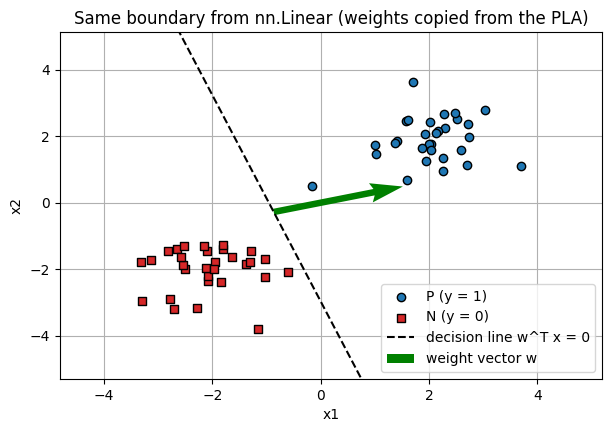

In [13]:
# Idiomatic PyTorch: a single linear layer plus a sign is a perceptron.
lin = nn.Linear(2, 1).to(device)
with torch.no_grad():
    lin.weight.copy_(w_learned[1:].reshape(1, 2).to(device))   # w1, w2
    lin.bias.copy_(w_learned[:1].to(device))                   # w0 = -theta (the bias)


def perceptron_nn(coords2d):
    coords2d = torch.as_tensor(coords2d, dtype=torch.float32, device=device)
    return (lin(coords2d).squeeze(-1) >= 0).long()


coords = X_t[:, 1:]                                            # drop the bias column
pred_nn = perceptron_nn(coords).cpu()
pred_scratch = (X_t @ w_learned >= 0).long()
print("nn.Linear matches the from-scratch perceptron on every point:",
      bool((pred_nn == pred_scratch).all()))

# Rebuild w from the layer parameters and confirm the identical boundary.
w_from_layer = torch.cat([lin.bias.detach().cpu().reshape(1),
                          lin.weight.detach().cpu().reshape(-1)])
fig, ax = plt.subplots()
plot_boundary(w_from_layer, X_np, y_np, ax=ax, xlim=XLIM, ylim=YLIM,
              title="Same boundary from nn.Linear (weights copied from the PLA)")
plt.show()

## Key takeaways

- The **MP neuron** sums Boolean inputs and thresholds at $\theta$; **inhibitory** inputs veto the output. Choosing $\theta$ (and inhibition) gives AND, OR, NOR and more.
- The **perceptron** adds real **weights**, and the **bias trick** ($x_0 = 1$, $w_0 = -\theta$) turns the firing rule into the tidy $w^\top x \ge 0$.
- The **Perceptron Learning Algorithm** nudges $w$ toward misclassified $P$ points and away from misclassified $N$ points, and it converges when the data are linearly separable.
- Geometrically, $w$ is the **normal** to the decision line. Adding $x$ raises $\cos \alpha$ by $\lVert x \rVert^2 > 0$, shrinking the angle toward the correct side: that is *why* the rule works.
- A perceptron is just an `nn.Linear` plus a sign; the from-scratch and PyTorch versions agree exactly.

## Exercises

- Move the blobs closer (raise `sigma` or shrink the gap between the means) until they overlap. What does the convergence curve do when the data are **not** linearly separable?
- The classic failure is **XOR**: no single line separates it. Set up the four XOR points and run the PLA. It will never converge, which motivates stacking neurons into a network in **Lecture 2**.